In [1]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import yfinance as yf

Making the data set of daily **Closing Prices** of 5 stocks Listed on BSE from **JAN 2023** to **DEC 2023** :

1.   "Zomato": "ZOMATO.BO"
2.   "Vedanta": "VEDL.BO"
3.   "Coal India": "COALINDIA.BO"
4.   "Biocon": "BIOCON.BO"
5.  "Suzlon": "SUZLON.BO"




In [2]:
# Define the stock tickers for the companies
tickers = {
    "Zomato": "ZOMATO.BO",
    "Vedanta": "VEDL.BO",
    "Suzlon": "SUZLON.BO",
    "Coal India": "COALINDIA.BO",
    "Biocon": "BIOCON.BO"
}

# Define the date range
start_date = "2023-01-01"
end_date = "2023-12-31"

# Create a dictionary to store the data
data = {}

# Fetch data for each ticker
for name, ticker in tickers.items():
    print(f"Fetching data for {name} ({ticker})...")
    stock_data = yf.download(ticker, start=start_date, end=end_date)["Close"]
    data[name] = stock_data

# Combine data into a single DataFrame with MultiIndex
df1 = pd.concat(data, axis=1)
df1.head()
df1.shape

Fetching data for Zomato (ZOMATO.BO)...


[*********************100%***********************]  1 of 1 completed


Fetching data for Vedanta (VEDL.BO)...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Fetching data for Suzlon (SUZLON.BO)...
Fetching data for Coal India (COALINDIA.BO)...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Fetching data for Biocon (BIOCON.BO)...


(230, 5)

<ipython-input-3-65ed29902c70>:3: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df1.iloc[:,i], label=df1.columns.values[i])


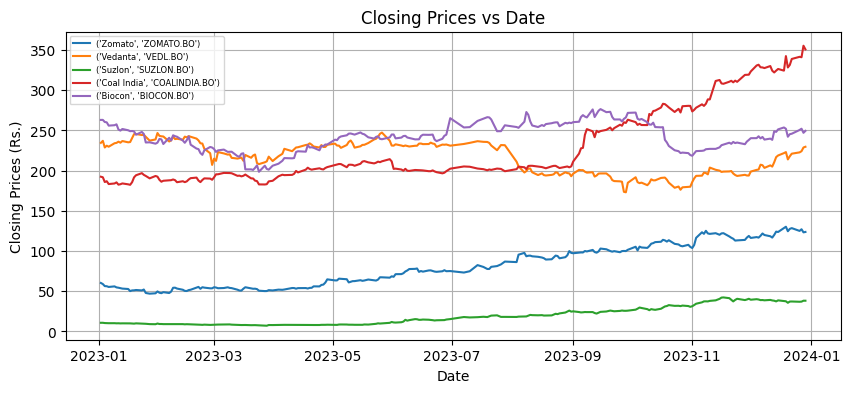

In [3]:
plt.figure(figsize=(10, 4))
for i in range(df1.shape[1]):
    plt.plot(df1.iloc[:,i], label=df1.columns.values[i])
plt.xlabel('Date')
plt.ylabel('Closing Prices (Rs.)')
plt.title('Closing Prices vs Date')
plt.grid(True)
plt.legend(loc='upper left', fontsize=6)
plt.show()


**Normalising the prices**
$$
\text{Normalized Price} = \frac{\text{Price} - \text{Min Price}}{\text{Max Price} - \text{Min Price}}
$$

<ipython-input-4-f901d60d6d12>:5: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df3.iloc[:,i], label=df3.columns.values[i])


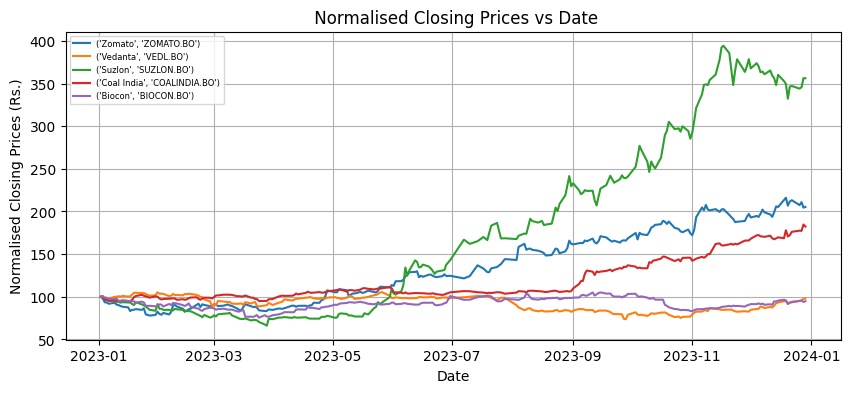

In [4]:
df3 = df1.divide(df1.iloc[0] / 100)

plt.figure(figsize=(10, 4))
for i in range(df3.shape[1]):
    plt.plot(df3.iloc[:,i], label=df3.columns.values[i])
plt.xlabel('Date')
plt.ylabel('Normalised Closing Prices (Rs.)')
plt.title(' Normalised Closing Prices vs Date')
plt.grid(True)
plt.legend(loc='upper left', fontsize=6)
plt.show()

**Calculating Daily Returns**
$$
\text{Daily Return % } = \frac{\text{Price}_{t} - \text{Price}_{t-1}}{\text{Price}_{t-1}} * 100
$$



In [5]:
#Calculate daily changes in the stocks' value
df2 = df1.pct_change()

**Calculating Annualized Return ($\mu$)** :
 number of business days each year  = 252
$$
\mu = \text{Annualized Rate of Return} = \left(1 + \text{Daily Return}\right)^{252} - 1
$$

In [6]:
#Remove nan values at the first row of df2. Create a new dataframe df
df=df2.iloc[1:len(df2.index),:]
# Calculate annualized average return for each stock. Annualized average return = Daily average return * 252 business days.
r = np.mean(df,axis=0)*252

$$
\text{Cov}(X_i, X_j) = \frac{\sum_{k=1}^{N} (X_{i,k} - \mu_{X_i})(X_{j,k} - \mu_{X_j})}{N-1}
$$



$$
\Sigma = \text{Covariance Matrix} =
\begin{pmatrix}
\text{Var}(X_1) & \text{Cov}(X_1, X_2) & \cdots & \text{Cov}(X_1, X_n) \\
\text{Cov}(X_2, X_1) & \text{Var}(X_2) & \cdots & \text{Cov}(X_2, X_n) \\
\vdots & \vdots & \ddots & \vdots \\
\text{Cov}(X_n, X_1) & \text{Cov}(X_n, X_2) & \cdots & \text{Var}(X_n)
\end{pmatrix}
$$


In [7]:
# Create a covariance matrix
covar = df.cov()
print(covar)

                           Zomato   Vedanta    Suzlon   Coal India    Biocon
Ticker                  ZOMATO.BO   VEDL.BO SUZLON.BO COALINDIA.BO BIOCON.BO
           Ticker                                                           
Zomato     ZOMATO.BO     0.000681  0.000101  0.000232     0.000063  0.000068
Vedanta    VEDL.BO       0.000101  0.000336  0.000088     0.000052  0.000037
Suzlon     SUZLON.BO     0.000232  0.000088  0.001274     0.000072  0.000020
Coal India COALINDIA.BO  0.000063  0.000052  0.000072     0.000232  0.000024
Biocon     BIOCON.BO     0.000068  0.000037  0.000020     0.000024  0.000319


so for these stocks we got our covarinace matrix $(\Sigma)$:
$$
\Sigma = \text{covar} =
\begin{pmatrix}
\text  0.000681 & 0.000101 & 0.000232 & 0.000063 & 0.000068 \\
\text 0.000101 & 0.000336 & 0.000088 & 0.000052 & 0.000037 \\
\text 0.000232 & 0.000088 & 0.001274 & 0.000072 & 0.000020 \\
\text 0.000063 & 0.000052 & 0.000072 & 0.000232 & 0.000024 \\
\text 0.000068 & 0.000037 & 0.000020 & 0.000024 & 0.000319 \\
\end{pmatrix}
$$



 * **Rate of return ($\mu_p$)** is the annualized rate of return for the whole portfolio.
 $$\mu_p = \mu  * x $$
-where
- $μ$ is Annualized Return of each stock
- $x$ is portion of each stock in our portfolio

In [8]:
#Define frequently used functions.
# r  = is each stock's return,
# x is the portion of each stock in our portfolio,

# Rate of return
def ret(r,x):
    return r.dot(x)

 * **Volatility** is the risk level, defined as the standard diviation of return.
$$
\text{Volatility} = \sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (R_i - \mu)^2}
\
$$
Where:
- $\sigma$  is the standard deviation (volatility).
- $ R_i $ is the return at time $ i $.
- $\mu$  is the average return.
- $ N $ is the number of periods.

In [9]:
def vol(x,covar):
    return np.sqrt(np.dot(x,np.dot(x,covar)))

 * **Sharpe ratio** is risk efficiency; it assesses the return of an investment compared to its risk.

 $$
 \text{Sharpe Ratio} = \frac{R_p }{\sigma_p}
 $$

 where:
  - $R_p$ is the average return of the portfolio.
  - $\sigma_p$ is the standard deviation of the portfolio’s excess return (volatility).

In [10]:
def sharpe (ret,vol):
    return ret/vol

All weights must be between 0 and 1 (as we cannot buy a negative amount of stocks, and we cannot form a portfolio with more than 100% of 1 stock).
The sum of weights of all stock must be 1.



In [16]:
# All weights, of course, must be between 0 and 1. Thus we set 0 and 1 as the boundaries.
#Setting Boundaries for Weights
from scipy.optimize import Bounds
bounds = Bounds(0, 1)

# The second boundary is the sum of weights.
#Defining the Sum of Weights Constraint
from scipy.optimize import LinearConstraint
linear_constraint = LinearConstraint(np.ones((df2.shape[1],), dtype=int),1,1)

# Find a portfolio with the minimum risk.
from scipy.optimize import minimize

#Initial Guess
#Create x0, the first guess at the values of each stock's weight.
weights = np.ones(df2.shape[1])
x0 = weights/np.sum(weights)


# Minimixing Risk (Volatility)


$
portfolio \space volatility (risk) = \sigma_p = \sqrt{x^T C x}
$

Where:

- $x$ is the vector of portion of each stock in our portfolio
- $C$ is the covariance matrix.
- ${x}^T$ is the transpose of ${x}$


In [29]:
#Define a function to calculate volatility
fun1 = lambda x: np.sqrt(np.dot(x,np.dot(x,covar)))
res = minimize(fun1,x0,method='trust-constr',constraints = linear_constraint,bounds = bounds)

#These are the weights of the stocks in the portfolio with the lowest level of risk possible.
x_min = res.x

In [30]:
np.set_printoptions(suppress = True, precision=2)

for i, name in enumerate(tickers):
  print(name, x_min[i])
print('return: % .4f'% (ret(r,x_min)*100), 'risk: % .4f'% vol(x_min,covar))

Zomato 0.058341955109808184
Vedanta 0.22313255801064652
Suzlon 0.03794760923900424
Coal India 0.38961845338998247
Biocon 0.29095942425055854
return:  37.8294 risk:  0.0107


In [31]:
# Print table header
print(f"{'Ticker':<15}{'Weight':<15}")
print("-" * 30)

# Print each ticker and its corresponding weight
for i, name in enumerate(tickers):
    print(f"{name:<15}{x_min[i]:<15.4f}")

# Print portfolio metrics
portfolio_return = ret(r, x_min) * 100  # Convert to percentage
portfolio_risk = vol(x_min, covar)
Sharpe = sharpe(portfolio_return/100, portfolio_risk)

print("\nPortfolio Metrics:")
print(f"{'Return:':<15}{portfolio_return:.4f}%")
print(f"{'Risk:':<15}{portfolio_risk:.4f}")
print(f"{'Sharpe Ratio:':<15}{Sharpe:.4f}")

Ticker         Weight         
------------------------------
Zomato         0.0583         
Vedanta        0.2231         
Suzlon         0.0379         
Coal India     0.3896         
Biocon         0.2910         

Portfolio Metrics:
Return:        37.8294%
Risk:          0.0107
Sharpe Ratio:  35.2124


# Maximizing Sharpe Ratio

- Objective Function: Reciprocal of Sharpe Ratio
$$ \text{Objective Function:} \quad \frac{\sigma_{\text{portfolio}}}{\mu_{\text{portfolio}}} $$

- Risk (Volatility)
$$ \sigma_{\text{portfolio}} = \sqrt{\mathbf{x}^T \mathbf{C} \mathbf{x}} $$

- Return
$$ \mu_{\text{portfolio}} = \mathbf{r}^T \mathbf{x} $$

- Sharpe Ratio (Maximizing)
$$ \text{Sharpe Ratio} = \frac{\mu_{\text{portfolio}}}{\sigma_{\text{portfolio}}} $$

In [33]:
#Define 1/Sharpe_ratio
fun2 = lambda x: np.sqrt(np.dot(x,np.dot(x,covar)))/r.dot(x)
res_sharpe = minimize(fun2,x0,method='trust-constr',constraints = linear_constraint,bounds = bounds)

#These are the weights of the stocks in the portfolio with the highest Sharpe ratio.
x_sharpe = res_sharpe.x

# Print table header
print(f"{'Ticker':<15}{'Weight':<15}")
print("-" * 30)

# Print each ticker and its corresponding weight
for i, name in enumerate(tickers):
    print(f"{name:<15}{x_sharpe[i]:<15.4f}")

# Print portfolio metrics
portfolio_return = ret(r, x_sharpe) * 100  # Convert to percentage
portfolio_risk = vol(x_sharpe, covar)
Sharpe = sharpe(portfolio_return/100, portfolio_risk)

print("\nPortfolio Metrics:")
print(f"{'Return:':<15}{portfolio_return:.4f}%")
print(f"{'Risk:':<15}{portfolio_risk:.4f}")
print(f"{'Sharpe Ratio:':<15}{Sharpe:.4f}")

Ticker         Weight         
------------------------------
Zomato         0.1765         
Vedanta        0.0000         
Suzlon         0.2273         
Coal India     0.5961         
Biocon         0.0000         

Portfolio Metrics:
Return:        92.0340%
Risk:          0.0149
Sharpe Ratio:  61.9289


# PLOTTING EFFICIENT FRONTIER

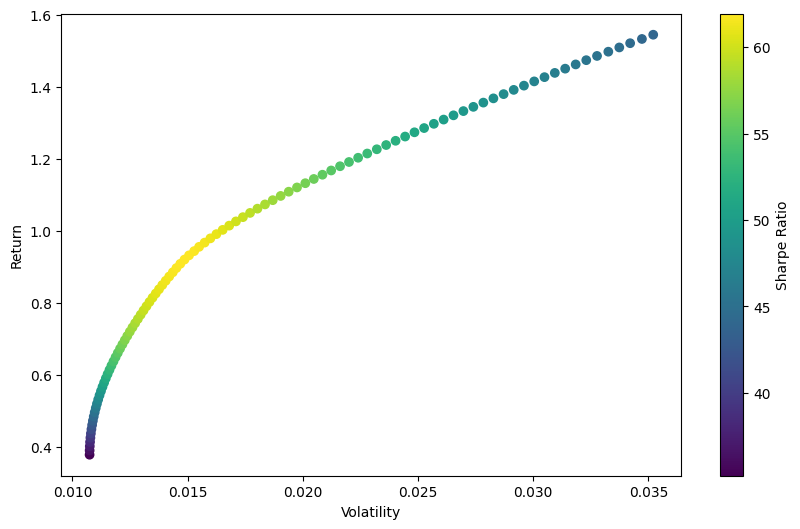

In [14]:
#Initialization:
#num_ports: The number of portfolios to compute along the efficient frontier.
#gap: Incremental difference in return between each portfolio.
x = x_min
num_ports = 100
gap = (np.amax(r) - ret(r,x_min))/num_ports

#Arrays for Storing Results:
# all_weights: Stores the portfolio weights for each point.
# ret_arr: Stores the expected return for each portfolio.
# vol_arr: Stores the volatility for each portfolio.
# The first two portfolios correspond to the minimum risk and maximum Sharpe ratio portfolios.
all_weights = np.zeros((num_ports, len(df.columns)))
all_weights[0],all_weights[1]=x_min,x_sharpe
ret_arr = np.zeros(num_ports)
ret_arr[0],ret_arr[1]=ret(r,x_min),ret(r,x_sharpe)
vol_arr = np.zeros(num_ports)
vol_arr[0],vol_arr[1]=vol(x_min,covar),vol(x_sharpe,covar)


#Efficient Frontier Calculation:
# double_constraint: Adds an additional constraint to match the desired portfolio return port_ret
# Optimization: Minimizes volatility under the given return constraint.
# Updates the weights, returns, and volatilities for each portfolio.
for i in range(num_ports):
    port_ret = ret(r,x) + i*gap
    double_constraint = LinearConstraint([np.ones(df2.shape[1]),r],[1,port_ret],[1,port_ret])

    #Create x0: initial guesses for weights.
    x0 = x_min
    #Define a function for portfolio volatility.
    fun = lambda x: np.sqrt(np.dot(x,np.dot(x,covar)))
    a = minimize(fun,x0,method='trust-constr',constraints = double_constraint,bounds = bounds)

    all_weights[i,:]=a.x
    ret_arr[i]=port_ret
    vol_arr[i]=vol(a.x,covar)

#Sharpe Ratio Calculation:
sharpe_arr = ret_arr/vol_arr

#PLOTTING
plt.figure(figsize=(10,6))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.show()